In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import os

os.makedirs("reports", exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


In [5]:
# ── Cell 2: Load saved model and test data ────────────────────
with open("C:\\Users\\User\\Desktop\\developer survey ML project\\training\\models\\model.pkl",        "rb") as f: model         = pickle.load(f)
with open("C:\\Users\\User\\Desktop\\developer survey ML project\\training\\models\\scaler.pkl",       "rb") as f: scaler        = pickle.load(f)
with open("C:\\Users\\User\\Desktop\\developer survey ML project\\training\\models\\feature_names.pkl","rb") as f: feature_names = pickle.load(f)

X_test_sc = pd.read_csv("C:\\Users\\User\\Desktop\\developer survey ML project\\training\\models\\X_test_sc.csv")
y_test    = pd.read_csv("C:\\Users\\User\\Desktop\\developer survey ML project\\training\\models\\y_test.csv")

print("Model type  :", type(model))
print("Features    :", len(feature_names))
print("Test rows   :", len(X_test_sc))
print("Feature names:", feature_names)

Model type  : <class 'sklearn.linear_model._ridge.Ridge'>
Features    : 36
Test rows   : 830
Feature names: ['years_code', 'work_exp', 'log_work_exp', 'education', 'org_size', 'remote_work', 'is_manager', 'is_fullstack', 'is_backend', 'is_frontend', 'is_ml', 'is_devops', 'is_mobile', 'lang_python', 'lang_rust', 'lang_go', 'lang_typescript', 'lang_kotlin', 'lang_scala', 'lang_swift', 'cloud_aws', 'cloud_azure', 'cloud_gcp', 'web_react', 'web_nextjs', 'web_fastapi', 'web_django', 'uses_ai_tools', 'work_exp_sq', 'n_cloud', 'n_hv_langs', 'n_webframes', 'exp_x_edu', 'exp_x_orgsize', 'manager_x_exp', 'ml_x_cloud']


In [6]:
# ── Cell 3: Load train data for explainer background ──────────
# LinearExplainer needs training data to compute the baseline
# (the average prediction — what SHAP values are measured against)

df       = pd.read_csv("data/survey_cleaned.csv")
X        = df.drop(columns=["salary", "log_salary"])
y_full   = df["log_salary"]

from sklearn.model_selection import train_test_split
X_train, _, y_train, _ = train_test_split(X, y_full, test_size=0.2, random_state=42)
# random_state=42 gives exact same split as train.ipynb

X_train_sc = pd.DataFrame(
    scaler.transform(X_train),   # use saved scaler — do NOT refit
    columns=feature_names
)

print("Train rows for background:", len(X_train_sc))

Train rows for background: 3319


In [7]:
# ── Cell 4: Compute SHAP values ───────────────────────────────
# LinearExplainer is exact for linear/ridge models
# No approximation — the math is:  SHAP_i = coef_i × (x_i - mean_i)

explainer   = shap.LinearExplainer(model, X_train_sc)
shap_values = explainer(X_test_sc)

print("SHAP values shape:", shap_values.values.shape)
# Should be (test_rows, 36) — one SHAP value per person per feature

# Quick sanity check
# Sum of all SHAP values for person 0 + baseline should equal their prediction
baseline    = shap_values.base_values[0]
shap_sum    = shap_values.values[0].sum()
prediction  = model.predict(X_test_sc.iloc[[0]])[0]

print(f"\nSanity check for person 0:")
print(f"  Baseline (mean log salary) : {baseline:.4f}")
print(f"  Sum of SHAP values         : {shap_sum:.4f}")
print(f"  Baseline + SHAP sum        : {baseline + shap_sum:.4f}")
print(f"  Model prediction           : {prediction:.4f}")
print(f"  Match: {abs((baseline + shap_sum) - prediction) < 0.0001}")
# This should print True — confirms SHAP is working correctly

SHAP values shape: (830, 36)

Sanity check for person 0:
  Baseline (mean log salary) : 11.9229
  Sum of SHAP values         : 0.1372
  Baseline + SHAP sum        : 12.0601
  Model prediction           : 12.0601
  Match: True


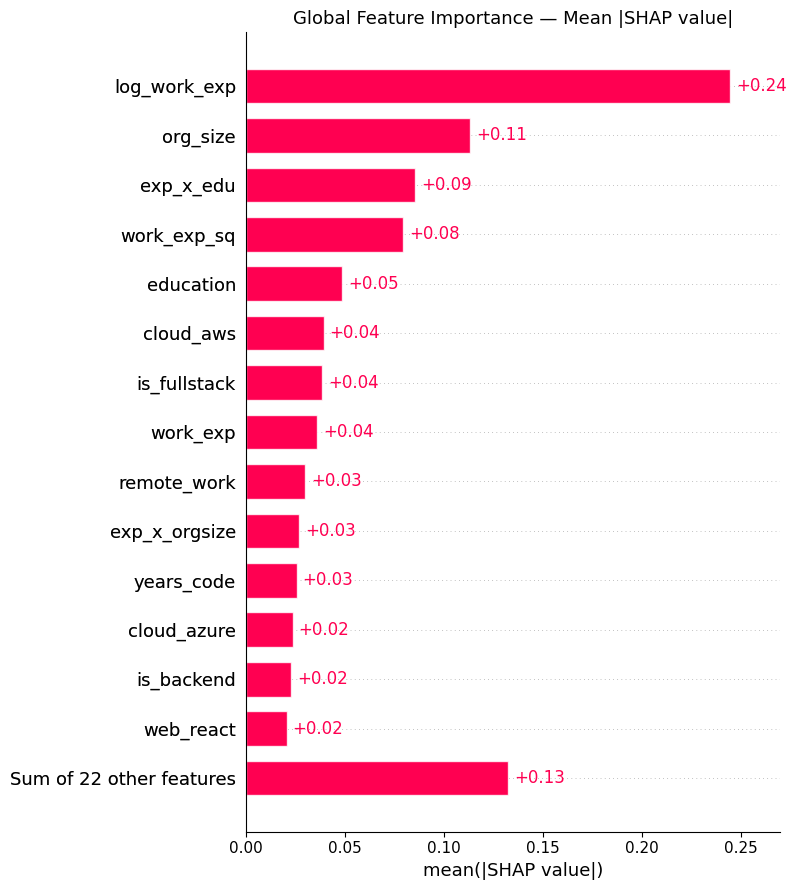

Saved → reports/shap_bar.png


In [8]:
# ── Cell 5: Plot 1 — Global bar chart ─────────────────────────
# Shows mean |SHAP| per feature — which features matter most on average
# This is similar to coefficients but weighted by actual feature variance

shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Global Feature Importance — Mean |SHAP value|", fontsize=13)
plt.tight_layout()
plt.savefig("reports/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/shap_bar.png")

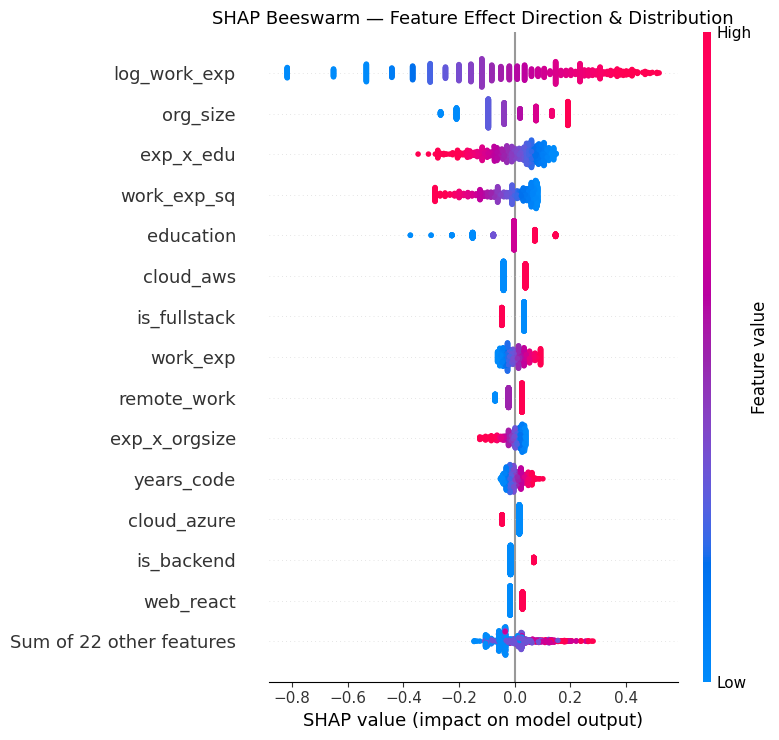

Saved → reports/shap_beeswarm.png


In [9]:
# ── Cell 6: Plot 2 — Beeswarm ─────────────────────────────────
# Each dot = one person from test set
# X position = SHAP value (how much this feature pushed their salary up/down)
# Color = their actual feature value (red = high, blue = low)
#
# What to look for:
# - log_work_exp: red dots on right = high experience → higher salary ✓
# - is_fullstack: should cluster slightly left (negative) ✓
# - org_size: red dots (big company) on right → higher salary ✓

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm — Feature Effect Direction & Distribution", fontsize=13)
plt.tight_layout()
plt.savefig("reports/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/shap_beeswarm.png")

Person 0:
  Actual salary   : $145,000
  Predicted salary: $172,837
  Error           : $27,837


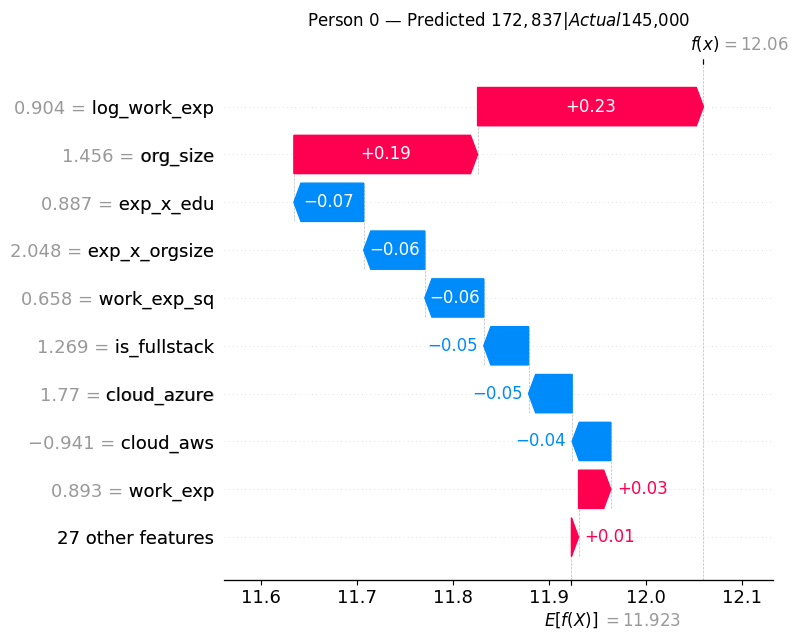

In [11]:
# ── Cell 7: Plot 3 — Waterfall for one person ─────────────────
person_idx    = 0

pred_log      = model.predict(X_test_sc.iloc[[person_idx]])[0]
pred_salary   = np.exp(pred_log)
actual_salary = np.exp(y_test.iloc[person_idx].item())  # .item() extracts scalar from Series

print(f"Person {person_idx}:")
print(f"  Actual salary   : ${actual_salary:,.0f}")
print(f"  Predicted salary: ${pred_salary:,.0f}")
print(f"  Error           : ${abs(actual_salary - pred_salary):,.0f}")

shap.plots.waterfall(shap_values[person_idx], show=False)
plt.title(f"Person {person_idx} — Predicted ${pred_salary:,.0f} | Actual ${actual_salary:,.0f}")
plt.tight_layout()
plt.savefig("reports/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── Cell 8: Compare a few people ──────────────────────────────
print(f"{'Person':<8} {'Actual':>12} {'Predicted':>12} {'Error':>10}")
print("-" * 46)
for i in range(5):
    actual    = np.exp(y_test.iloc[i].item())   # .item() here too
    predicted = np.exp(model.predict(X_test_sc.iloc[[i]])[0])
    error     = actual - predicted
    print(f"{i:<8} ${actual:>11,.0f} ${predicted:>11,.0f} ${error:>+10,.0f}")

Person         Actual    Predicted      Error
----------------------------------------------
0        $    145,000 $    172,837 $   -27,837
1        $    177,000 $    136,993 $   +40,007
2        $     64,000 $     56,031 $    +7,969
3        $    159,000 $    148,318 $   +10,682
4        $    170,000 $    133,214 $   +36,786
